In [2]:
import datetime
from suntime import Sun

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

Tool: check sunrise/sunset time

In [4]:
# city: London
city_lat = 51.50
city_lon = -0.118

In [5]:
sun = Sun(city_lat, city_lon)

In [6]:
# Get today's sunrise and sunset in UTC
today_sr = sun.get_sunrise_time()
today_ss = sun.get_sunset_time()
print('Today the sun raised at {} and get down at {} UTC'.
      format(today_sr.strftime('%H:%M'), today_ss.strftime('%H:%M')))

# On a special date in your machine's local time zone
date = datetime.datetime.now()
print('Date: ', date)
print('Date: ', date.strftime('%Y-%m-%d %H:%M:%S'))

Today the sun raised at 06:53 and get down at 17:34 UTC
Date:  2025-02-26 15:47:36.039198
Date:  2025-02-26 15:47:36


In [7]:
# Get the sunrise and sunset for a specific date
date = datetime.datetime(2020, 12, 21)
print('Date: ', date)
print('Date: ', date.strftime('%Y-%m-%d %H:%M:%S'))
sunrise = sun.get_sunrise_time(date)
sunset = sun.get_sunset_time(date)
print('On 2020-12-21 the sun raised at {} and get down at {}'.
      format(sunrise.strftime('%H:%M'), sunset.strftime('%H:%M')))
print('On 2020-12-21 the sun raised at {} and get down at {}'.
        format(sunrise.tzinfo, sunset.tzinfo))

Date:  2020-12-21 00:00:00
Date:  2020-12-21 00:00:00
On 2020-12-21 the sun raised at 08:04 and get down at 15:53
On 2020-12-21 the sun raised at UTC and get down at UTC


_Visualization photoperiod_

In [8]:
# Directory
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [9]:
df = pd.read_excel(fpath + '\\1.0_sunset_sunrise_UTC.xlsx', sheet_name='Sheet2')

In [10]:
def adjust_value(row):
    timeshift = row['DST(0=ST)']
    
    if timeshift == 1:
                return row['sunrise (uk), hours'] + 1, row['sunset (uk), hours'] + 1, row['sunrise (ita), hours'] + 2, row['sunset (ita), hours'] + 2
    elif timeshift == 0:
                return row['sunrise (uk), hours'] - 0, row['sunset (uk), hours'] - 0, row['sunrise (ita), hours'] + 1, row['sunset (ita), hours'] + 1
    
    return row['sunrise (uk), hours'], row['sunset (uk), hours'], row['sunrise (ita), hours'], row['sunset (ita), hours']

df[['sunrise (uk), hours_adjust', 'sunset (uk), hours_adjust', 'sunrise (ita), hours_adjust', 'sunset (ita), hours_adjust']] = df.apply(adjust_value, axis=1, result_type='expand')

In [11]:
df['month'] = df['date'].dt.month

In [12]:
df['year'] = df['date'].dt.year

In [13]:
# Function to convert hours to hh:mm format
def hours_to_hhmm(x, pos):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return f'{hours:02d}:{minutes:02d}'

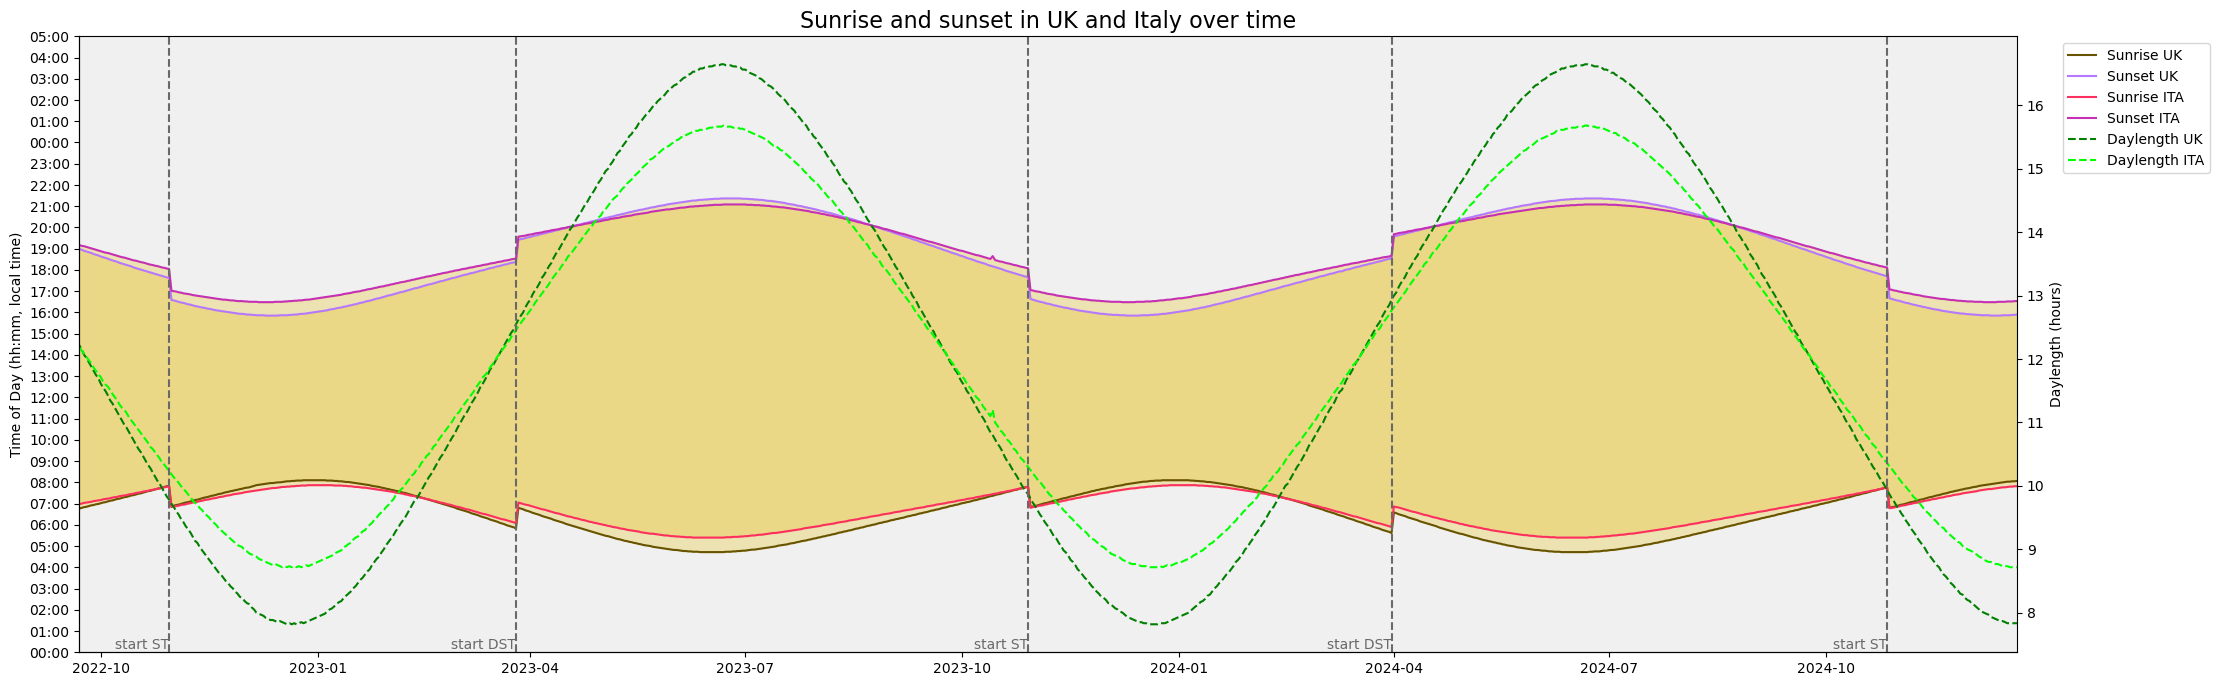

In [14]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df, label='Sunrise UK', color='#675300', ax=ax1)
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df, label='Sunset UK', color='#b578ff', ax=ax1)

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df, label='Sunrise ITA', color='#fd2f60', ax=ax1)
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df, label='Sunset ITA', color='#c530b4', ax=ax1)

# Fill between sunrise and sunset
plt.fill_between(df['date'], df['sunrise (uk), hours_adjust'], df['sunset (uk), hours_adjust'], color='#e9c323', alpha=0.3)
plt.fill_between(df['date'], df['sunrise (ita), hours_adjust'], df['sunset (ita), hours_adjust'], color='#e9c323', alpha=0.3)

# Add a third y-axis for daylight length
ax2 = ax1.twinx()
sns.lineplot(x='date', y=df['sunset (uk), hours_adjust'] - df['sunrise (uk), hours_adjust'], data=df, ax=ax2, label='Daylength UK', color='green', linestyle='--')
sns.lineplot(x='date', y=df['sunset (ita), hours_adjust'] - df['sunrise (ita), hours_adjust'], data=df, ax=ax2, label='Daylength ITA', color='lime', linestyle='--')

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Time of Day (hh:mm, local time)')
ax1.set_title('Sunrise and sunset in UK and Italy over time', fontsize=16)
ax2.set_ylabel('Daylength (hours)')

# Remove space y axis and plot
plt.gca().margins(x=0)

# Format y-axis to hh:mm
ax1.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval on y-axis
ax1.set_yticks(range(0, 30, 1))
ax1.set_yticklabels([hours_to_hhmm(i % 24, None) for i in range(0, 30, 1)])

#set ax2 y interval
ax2.set_yticks(range(8, 17, 1))

# Remove space y axis and plot
ax1.margins(x=0)

# Adding legend to the right of the plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.get_legend().remove()

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-22'), pd.to_datetime('2024-12-21'))

plt.show()

In [15]:
# Filter the data and create different dataframe for the year 2022, 2023 and 2024 only
df_2022 = df[df['date'].dt.year == 2022]
df_2023 = df[df['date'].dt.year == 2023]
df_2024 = df[df['date'].dt.year == 2024]
df_2025 = df[df['date'].dt.year == 2025]

_2022_

In [16]:
# Grouping by month and averaging sunrise and sunset times for both UK and ITA
monthly_avg = df_2022.groupby('month').agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

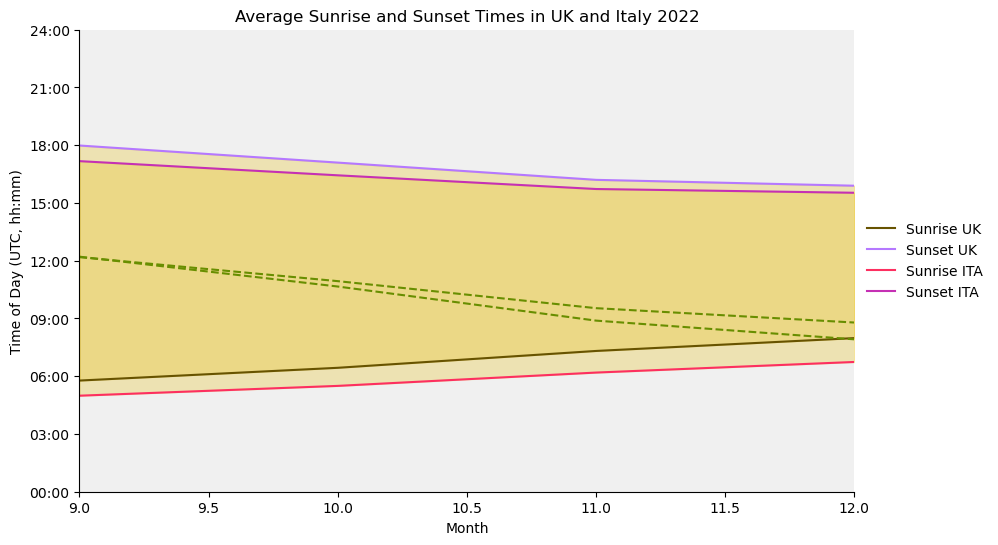

In [17]:
# Plot with averaged data
plt.figure(figsize=(10, 6))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
plt.gca().set_facecolor('#f0f0f0')

# UK sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], label='Sunrise UK', color='#675300')
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'], label='Sunset UK', color='#b578ff')

# ITA sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], label='Sunrise ITA', color='#fd2f60')
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'], label='Sunset ITA', color='#c530b4')

# Daylight length 
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'] - monthly_avg['sunrise (uk), hours'], label='Daylength UK', color='#688e00', linestyle='--',)
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'] - monthly_avg['sunrise (ita), hours'], label='Daylength ITA', color='#688e00', linestyle='--')

# Annotation on daylight length
#plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
#plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], monthly_avg['sunset (uk), hours'], color='#e9c323', alpha=0.3)
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], monthly_avg['sunset (ita), hours'], color='#e9c323', alpha=0.3)

#plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (UTC, hh:mm)')
plt.title('Average Sunrise and Sunset Times in UK and Italy 2022')

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# Change y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Remove space y axis and plot
plt.gca().margins(x=0)

# Adding legend to the right of the plot, excluding daylight length
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.show()

_2023_

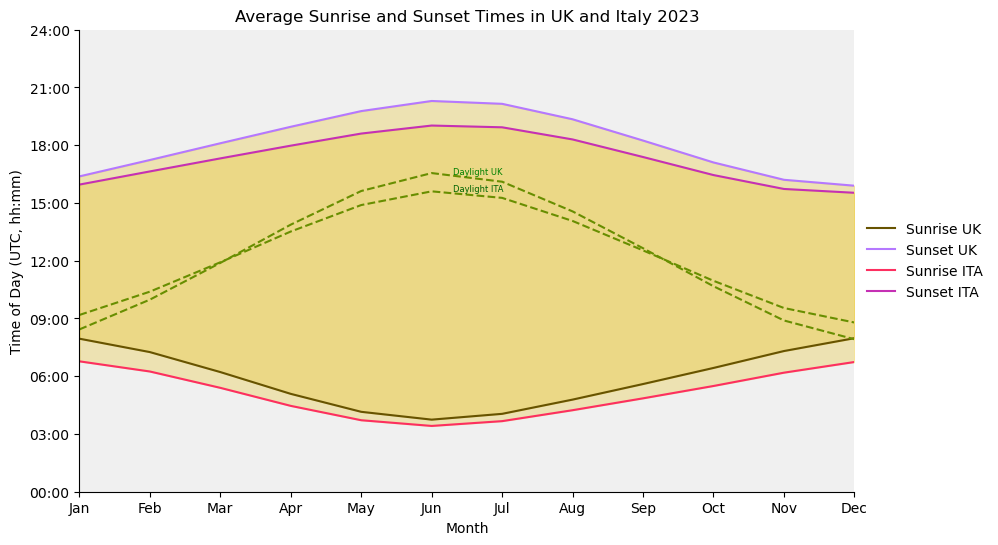

In [18]:
# Grouping by month and averaging sunrise and sunset times for both UK and ITA
monthly_avg = df_2023.groupby('month').agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

# plot with averaged data
plt.figure(figsize=(10, 6))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
plt.gca().set_facecolor('#f0f0f0')

# UK sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], label='Sunrise UK', color='#675300')
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'], label='Sunset UK', color='#b578ff')

# ITA sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], label='Sunrise ITA', color='#fd2f60')
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'], label='Sunset ITA', color='#c530b4')

# Daylight length 
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'] - monthly_avg['sunrise (uk), hours'], label='Daylength UK', color='#688e00', linestyle='--',)
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'] - monthly_avg['sunrise (ita), hours'], label='Daylength ITA', color='#688e00', linestyle='--')

# Annotation on daylight length
plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], monthly_avg['sunset (uk), hours'], color='#e9c323', alpha=0.3)
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], monthly_avg['sunset (ita), hours'], color='#e9c323', alpha=0.3)

plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (UTC, hh:mm)')
plt.title('Average Sunrise and Sunset Times in UK and Italy 2023')

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# Change y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Remove space y axis and plot
plt.gca().margins(x=0)

# Adding legend to the right of the plot, excluding daylight length
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.show()

_2024_

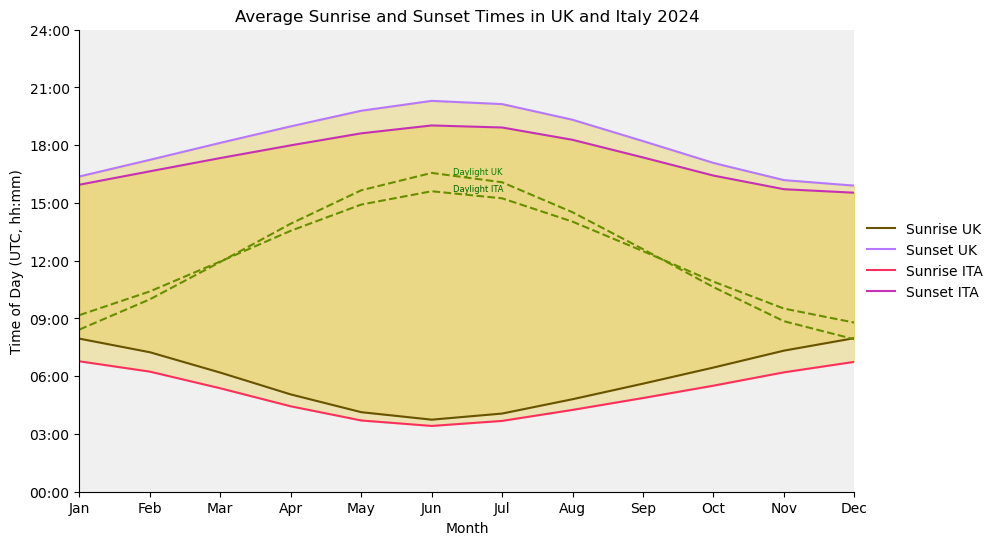

In [19]:
# Grouping by month and averaging sunrise and sunset times for both UK and ITA
monthly_avg = df_2024.groupby('month').agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

# plot with averaged data
plt.figure(figsize=(10, 6))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
plt.gca().set_facecolor('#f0f0f0')

# UK sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], label='Sunrise UK', color='#675300')
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'], label='Sunset UK', color='#b578ff')

# ITA sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], label='Sunrise ITA', color='#fd2f60')
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'], label='Sunset ITA', color='#c530b4')

# Daylight length 
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'] - monthly_avg['sunrise (uk), hours'], label='Daylength UK', color='#688e00', linestyle='--',)
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'] - monthly_avg['sunrise (ita), hours'], label='Daylength ITA', color='#688e00', linestyle='--')

# Annotation on daylight length
plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], monthly_avg['sunset (uk), hours'], color='#e9c323', alpha=0.3)
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], monthly_avg['sunset (ita), hours'], color='#e9c323', alpha=0.3)

plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (UTC, hh:mm)')
plt.title('Average Sunrise and Sunset Times in UK and Italy 2024')

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# Change y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Remove space y axis and plot
plt.gca().margins(x=0)

# Adding legend to the right of the plot, excluding daylight length
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.show()

_2022, 2023, 2024_

In [20]:
# Grouping by both year and month to calculate average sunrise and sunset times for each year and month
df['year'] = df['date'].dt.year

# Group by both year and month
yearly_monthly_avg = df.groupby(['year', 'month']).agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

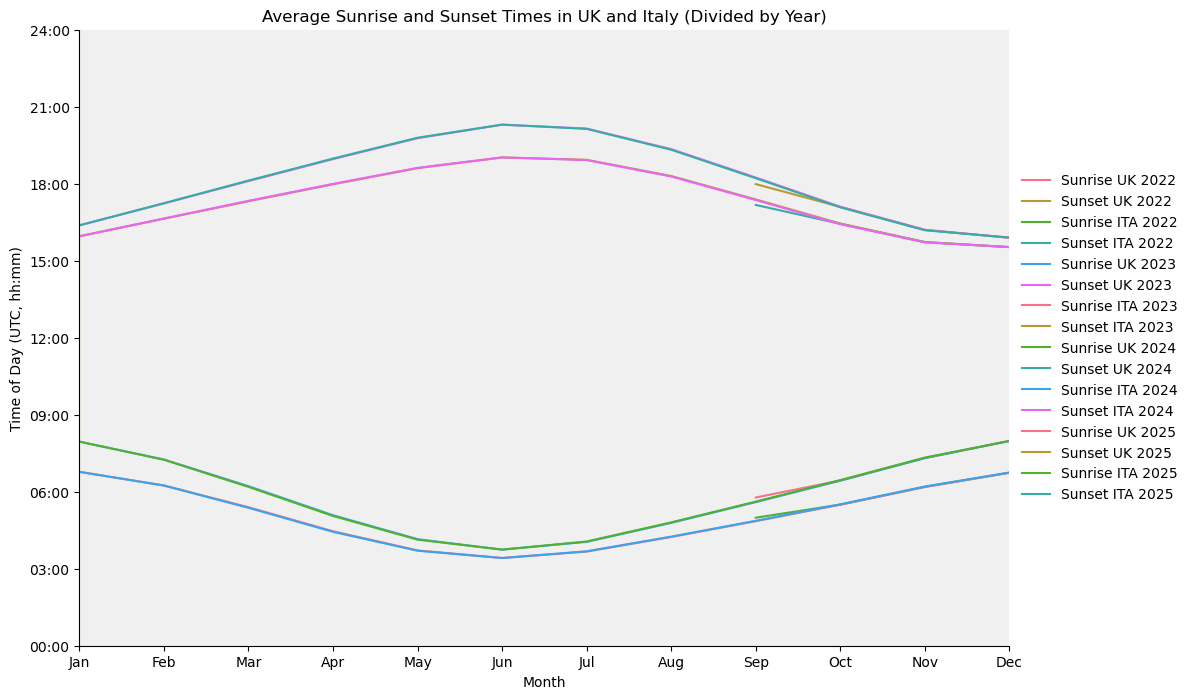

In [21]:
# Plotting the sunrise and sunset times divided by year
plt.figure(figsize=(12, 8))

sns.set_palette('husl')

# Plotting for each year separately
for year in yearly_monthly_avg['year'].unique():
    subset = yearly_monthly_avg[yearly_monthly_avg['year'] == year]
    
    # UK sunrise and sunset
    plt.plot(subset['month'], subset['sunrise (uk), hours'], label=f'Sunrise UK {year}', linestyle='-')
    plt.plot(subset['month'], subset['sunset (uk), hours'], label=f'Sunset UK {year}', linestyle='-')

    # ITA sunrise and sunset
    plt.plot(subset['month'], subset['sunrise (ita), hours'], label=f'Sunrise ITA {year}', linestyle='-')
    plt.plot(subset['month'], subset['sunset (ita), hours'], label=f'Sunset ITA {year}', linestyle='-')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.gca().set_facecolor('#f0f0f0')

plt.fill_between(subset['month'], subset['sunrise (uk), hours'], subset['sunset (uk), hours'], color='#e9c323', alpha=0.3)
plt.fill_between(subset['month'], subset['sunrise (ita), hours'], subset['sunset (ita), hours'], color='#e9c323', alpha=0.3)

# Add month names to the x-axis
plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Daylight length
plt.plot(subset['month'], subset['sunset (uk), hours'] - subset['sunrise (uk), hours'], label='Daylength UK', color='#688e00', linestyle='--',)
plt.plot(subset['month'], subset['sunset (ita), hours'] - subset['sunrise (ita), hours'], label='Daylength ITA', color='#688e00', linestyle='--')

# Add annotation daylight on daylight length lines
#plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
#plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# Y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (UTC, hh:mm)')
plt.title('Average Sunrise and Sunset Times in UK and Italy (Divided by Year)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.gca().margins(x=0)

plt.show()